# 02 - Exploratory analysis

**Appliance energy forecasting**

This notebook explores the cleaned hourly series produced by
`01_data_download_and_cleaning.ipynb`. 

**Input**

```text
data/processed/appliance_hourly.csv
```

**Figures produced**

```text
outputs/figures/02_target_distribution.png
outputs/figures/02_series_overview.png
outputs/figures/02_daily_profiles.png
outputs/figures/02_seasonal_profiles.png
outputs/figures/02_hour_dow_heatmap.png
outputs/figures/02_periodogram.png
outputs/figures/02_stl_decomposition.png
outputs/figures/02_mstl_decomposition.png
outputs/figures/02_acf_pacf.png
outputs/figures/02_acf_differenced.png
outputs/figures/02_rolling_stats.png
outputs/figures/02_correlation_heatmap.png
outputs/figures/02_lagged_correlation.png
```

## 1. Setup

In [1]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller, kpss
from statsmodels.tsa.seasonal import STL, MSTL

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# 2. Configuration

def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

TARGET = "Appliances"

DAILY_PERIOD = 24
WEEKLY_PERIOD = 168

TEST_STEPS = 14 * 24
HORIZON = 24


def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path)

    return path


print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [3]:
# 3. Load the processed hourly dataset

data = pd.read_csv(
    PROCESSED_DIR / "appliance_hourly.csv",
    index_col=0,
    parse_dates=True,
)

# asfreq makes the hourly frequency explicit, which statsmodels relies on.
data = data.asfreq("h")

y = data[TARGET]

print("Shape:", data.shape)
print("Period:", data.index.min(), "to", data.index.max())
print("Frequency:", data.index.freqstr)
print("Missing target values:", int(y.isna().sum()))

data.head()

Shape: (3289, 26)
Period: 2016-01-11 17:00:00 to 2016-05-27 17:00:00
Frequency: h
Missing target values: 0


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,17.615556,74.027778,5.469444,86.933889,17.632222,42.920000,18.773333,50.195556,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,18.427222,69.037778,5.578889,86.129444,17.863611,43.618333,19.153333,49.542222,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667


## 2. Distribution of the target

In [4]:
# 4. Summary statistics

summary = pd.Series({
    "n": len(y),
    "mean": y.mean(),
    "std": y.std(),
    "min": y.min(),
    "q05": y.quantile(0.05),
    "median": y.median(),
    "q95": y.quantile(0.95),
    "max": y.max(),
    "skew": y.skew(),
    "kurtosis": y.kurtosis(),
    "coef_of_variation": y.std() / y.mean(),
})

print(summary.round(3).to_string())

print("\nShare of hours above twice the median:", round(float((y > 2 * y.median()).mean()), 3))

n                    3289.000
mean                   97.678
std                    81.019
min                    28.333
q05                    38.333
median                 63.333
q95                   276.667
max                   608.333
skew                    2.389
kurtosis                6.346
coef_of_variation       0.829

Share of hours above twice the median: 0.208


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_target_distribution.png


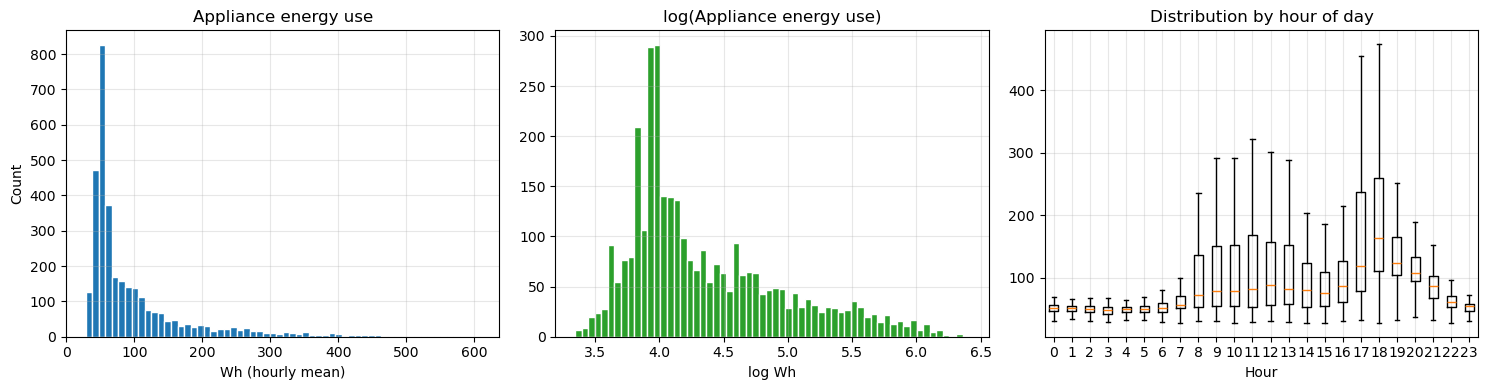

Skew, original scale: 2.389
Skew, log scale     : 0.995


In [5]:
# 5. Distribution on the original and log scales

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y, bins=60, color="tab:blue", edgecolor="white")
axes[0].set_title("Appliance energy use")
axes[0].set_xlabel("Wh (hourly mean)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log(y), bins=60, color="tab:green", edgecolor="white")
axes[1].set_title("log(Appliance energy use)")
axes[1].set_xlabel("log Wh")

axes[2].boxplot(
    [y[y.index.hour == h].values for h in range(24)],
    tick_labels=[str(h) for h in range(24)],
    showfliers=False,
)
axes[2].set_title("Distribution by hour of day")
axes[2].set_xlabel("Hour")

fig.tight_layout()
save_fig(fig, "02_target_distribution.png")

plt.show()

print("Skew, original scale:", round(float(y.skew()), 3))
print("Skew, log scale     :", round(float(np.log(y).skew()), 3))

## 3. Visual inspection of the series

Three time scales are needed to see the structure: the full record (trend and level
shifts), a single month (weekly rhythm), and a single week (daily rhythm).

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_series_overview.png


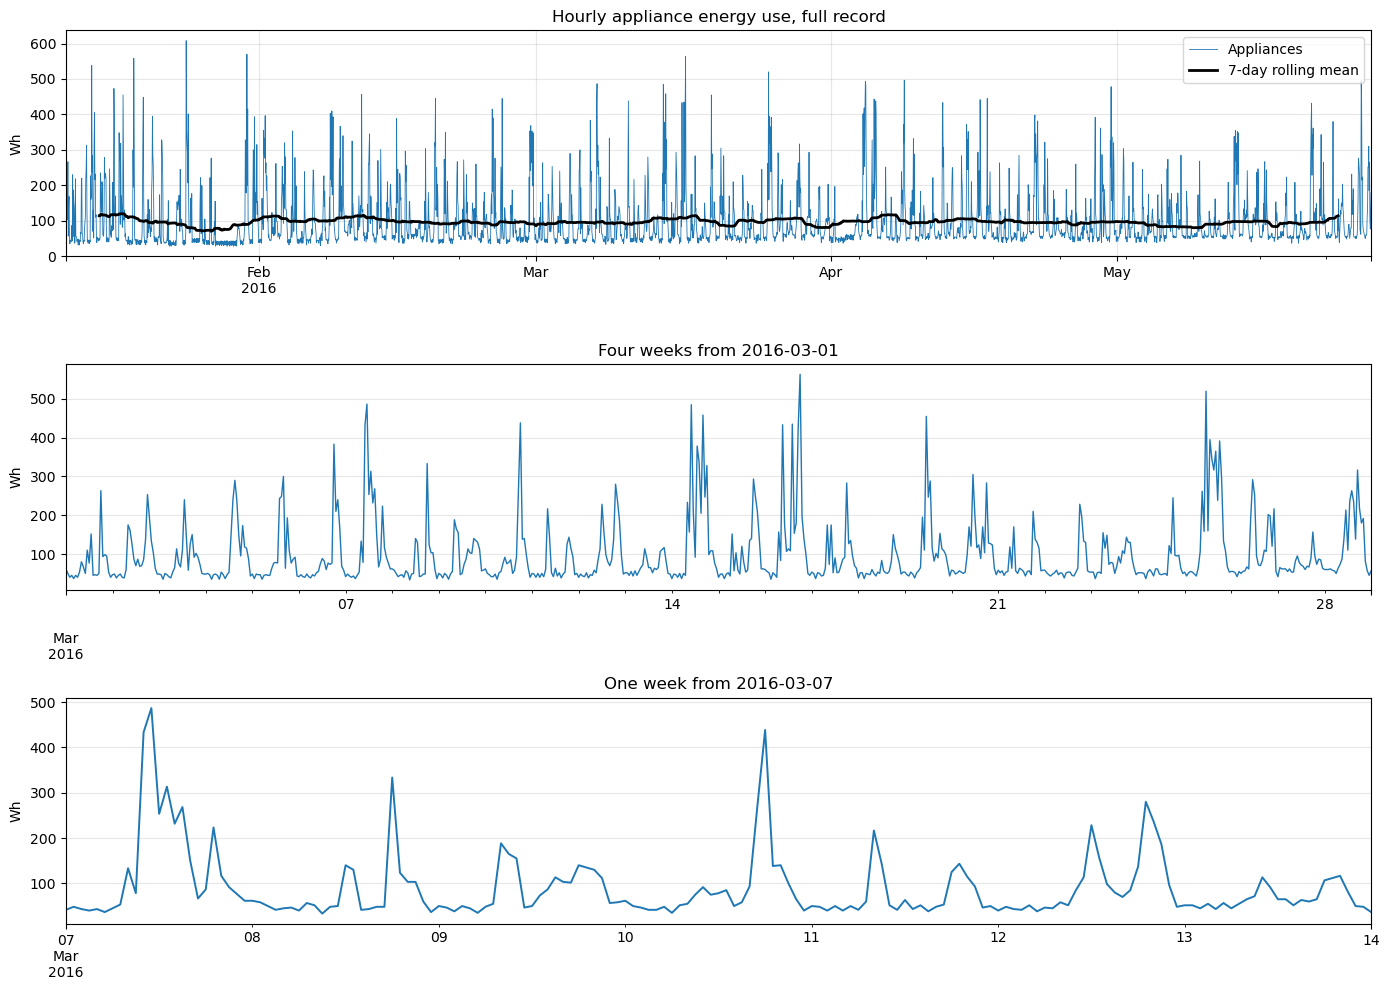

In [6]:
# 6. Full series, one month, one week

month_start = pd.Timestamp("2016-03-01")
month_end = month_start + pd.Timedelta(days=28)

week_start = pd.Timestamp("2016-03-07")
week_end = week_start + pd.Timedelta(days=7)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

y.plot(ax=axes[0], linewidth=0.6, color="tab:blue")
y.rolling(24 * 7, center=True).mean().plot(
    ax=axes[0], color="black", linewidth=2, label="7-day rolling mean"
)
axes[0].set_title("Hourly appliance energy use, full record")
axes[0].legend()

y.loc[month_start:month_end].plot(ax=axes[1], linewidth=1.0, color="tab:blue")
axes[1].set_title(f"Four weeks from {month_start.date()}")

y.loc[week_start:week_end].plot(ax=axes[2], linewidth=1.4, color="tab:blue")
axes[2].set_title(f"One week from {week_start.date()}")

for ax in axes:
    ax.set_ylabel("Wh")
    ax.set_xlabel("")

fig.tight_layout()
save_fig(fig, "02_series_overview.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_daily_profiles.png


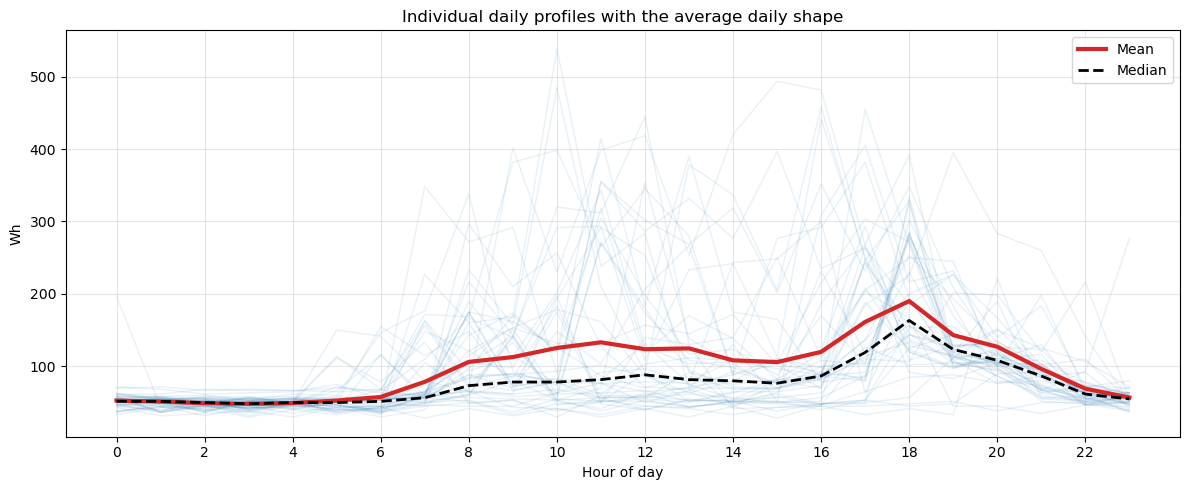

In [7]:
# 7. Daily profiles overlaid

fig, ax = plt.subplots(figsize=(12, 5))

by_day = y.groupby(y.index.normalize())

for _, day in list(by_day)[::3]:
    if len(day) == 24:
        ax.plot(range(24), day.values, color="tab:blue", alpha=0.10, linewidth=1)

hourly_mean = y.groupby(y.index.hour).mean()
hourly_median = y.groupby(y.index.hour).median()

ax.plot(hourly_mean.index, hourly_mean.values, color="tab:red", linewidth=3, label="Mean")
ax.plot(hourly_median.index, hourly_median.values, color="black", linewidth=2,
        linestyle="--", label="Median")

ax.set_title("Individual daily profiles with the average daily shape")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Wh")
ax.set_xticks(range(0, 24, 2))
ax.legend()

fig.tight_layout()
save_fig(fig, "02_daily_profiles.png")

plt.show()

## 4. Seasonal structure

Two candidate seasonal periods are examined: daily (period 24) and weekly
(period 168).

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_seasonal_profiles.png


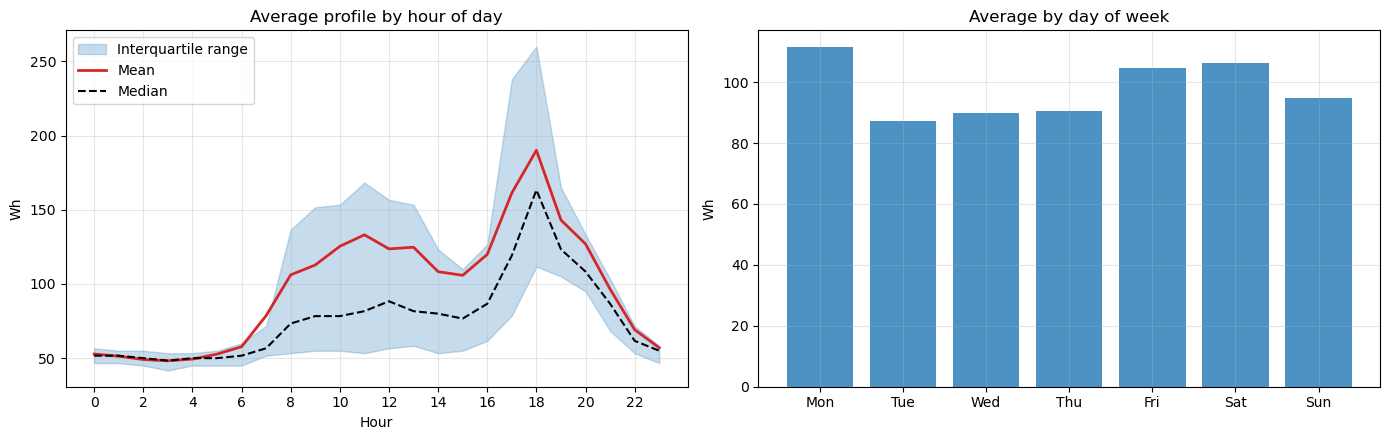

       mean  median    q25    q75
hour                             
0      52.8    51.7   46.7   56.7
1      51.3    51.7   46.7   55.0
2      49.1    50.0   45.0   55.0
3      48.2    48.3   41.7   53.3
4      49.4    50.0   45.0   53.3
5      52.7    50.0   45.0   55.0
6      57.7    51.7   45.0   60.0
7      78.6    56.7   51.7   71.7
8     106.1    73.3   53.3  136.7
9     112.8    78.3   55.0  151.7
10    125.4    78.3   55.0  153.3
11    133.1    81.7   53.3  168.3
12    123.6    88.3   56.7  156.7
13    124.7    81.7   58.3  153.3
14    108.3    80.0   53.3  123.3
15    105.8    76.7   55.0  110.0
16    119.9    86.7   61.7  126.7
17    161.4   119.2   78.8  237.9
18    190.1   163.3  111.7  260.0
19    143.1   123.3  105.0  165.0
20    127.0   108.3   95.0  133.3
21     96.5    86.7   68.3  103.3
22     69.1    61.7   53.3   71.7
23     57.0    55.0   46.7   58.3

      mean  median
Mon  111.5    63.3
Tue   87.1    56.7
Wed   89.9    68.3
Thu   90.4    58.3
Fri  104.5    60.0
S

In [8]:
# 8. Hour-of-day and day-of-week profiles

frame = pd.DataFrame({
    TARGET: y,
    "hour": y.index.hour,
    "dayofweek": y.index.dayofweek,
    "date": y.index.normalize(),
})

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

hour_stats = frame.groupby("hour")[TARGET].agg(["mean", "median",
                                                lambda s: s.quantile(0.25),
                                                lambda s: s.quantile(0.75)])
hour_stats.columns = ["mean", "median", "q25", "q75"]

dow_stats = frame.groupby("dayofweek")[TARGET].agg(["mean", "median"])
dow_stats.index = DAY_NAMES

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].fill_between(hour_stats.index, hour_stats["q25"], hour_stats["q75"],
                     alpha=0.25, color="tab:blue", label="Interquartile range")
axes[0].plot(hour_stats.index, hour_stats["mean"], color="tab:red", linewidth=2, label="Mean")
axes[0].plot(hour_stats.index, hour_stats["median"], color="black", linewidth=1.5,
             linestyle="--", label="Median")
axes[0].set_title("Average profile by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Wh")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

axes[1].bar(dow_stats.index, dow_stats["mean"], color="tab:blue", alpha=0.8)
axes[1].set_title("Average by day of week")
axes[1].set_ylabel("Wh")

fig.tight_layout()
save_fig(fig, "02_seasonal_profiles.png")

plt.show()

print(hour_stats.round(1).to_string())
print()
print(dow_stats.round(1).to_string())

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_hour_dow_heatmap.png


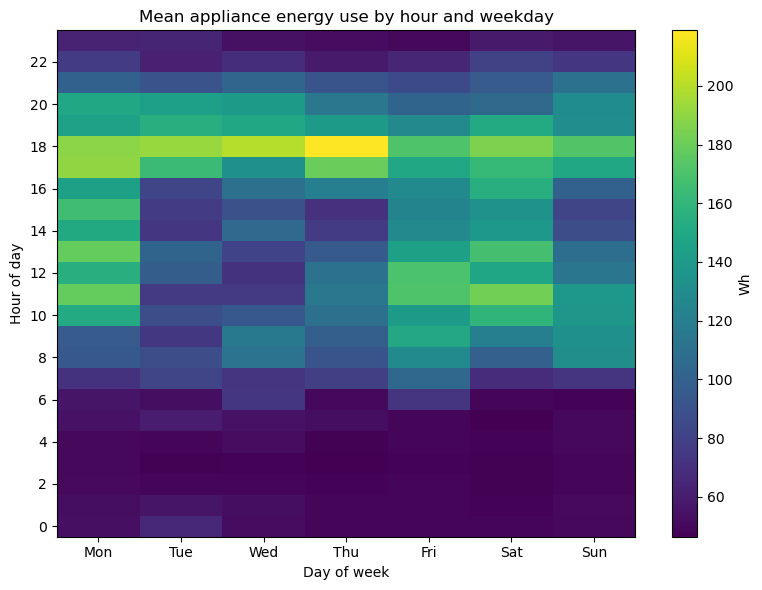

In [9]:
# 9. Hour x day-of-week heatmap

pivot = frame.pivot_table(
    index="hour",
    columns="dayofweek",
    values=TARGET,
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="viridis")

ax.set_xticks(range(7), DAY_NAMES)
ax.set_yticks(range(0, 24, 2), [str(h) for h in range(0, 24, 2)])
ax.set_xlabel("Day of week")
ax.set_ylabel("Hour of day")
ax.set_title("Mean appliance energy use by hour and weekday")
ax.grid(False)

fig.colorbar(mesh, ax=ax, label="Wh")

fig.tight_layout()
save_fig(fig, "02_hour_dow_heatmap.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_periodogram.png


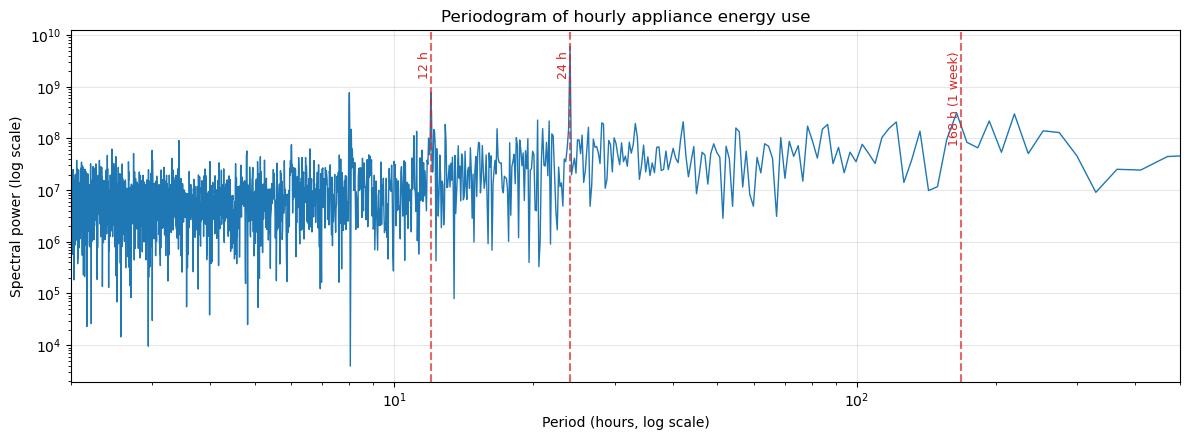

Strongest periodic components between 4 and 400 hours:
24.007299     6.069565e+09
12.003650     7.776253e+08
8.002433      7.711162e+08
164.450000    3.116506e+08
219.266667    2.987881e+08
12.047619     2.879315e+08
7.983010      2.491811e+08
20.428571     2.264703e+08


In [10]:
# 10. Frequency domain: where is the periodic energy?

centred = (y - y.mean()).values

spectrum = np.abs(np.fft.rfft(centred)) ** 2
freqs = np.fft.rfftfreq(len(centred), d=1.0)   # cycles per hour

mask = freqs > 0
periods = 1.0 / freqs[mask]
power = spectrum[mask]

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(periods, power, color="tab:blue", linewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(2, 500)
ax.set_xlabel("Period (hours, log scale)")
ax.set_ylabel("Spectral power (log scale)")
ax.set_title("Periodogram of hourly appliance energy use")

for period, label in [(12, "12 h"), (24, "24 h"), (168, "168 h (1 week)")]:
    ax.axvline(period, color="tab:red", linestyle="--", alpha=0.7)
    ax.text(period, ax.get_ylim()[1] * 0.4, label, rotation=90,
            va="top", ha="right", color="tab:red", fontsize=9)

fig.tight_layout()
save_fig(fig, "02_periodogram.png")

plt.show()

peaks = pd.Series(power, index=periods)
print("Strongest periodic components between 4 and 400 hours:")
print(peaks.loc[(peaks.index > 4) & (peaks.index < 400)].nlargest(8).round(0).to_string())

## 5. Decomposition into components

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_stl_decomposition.png


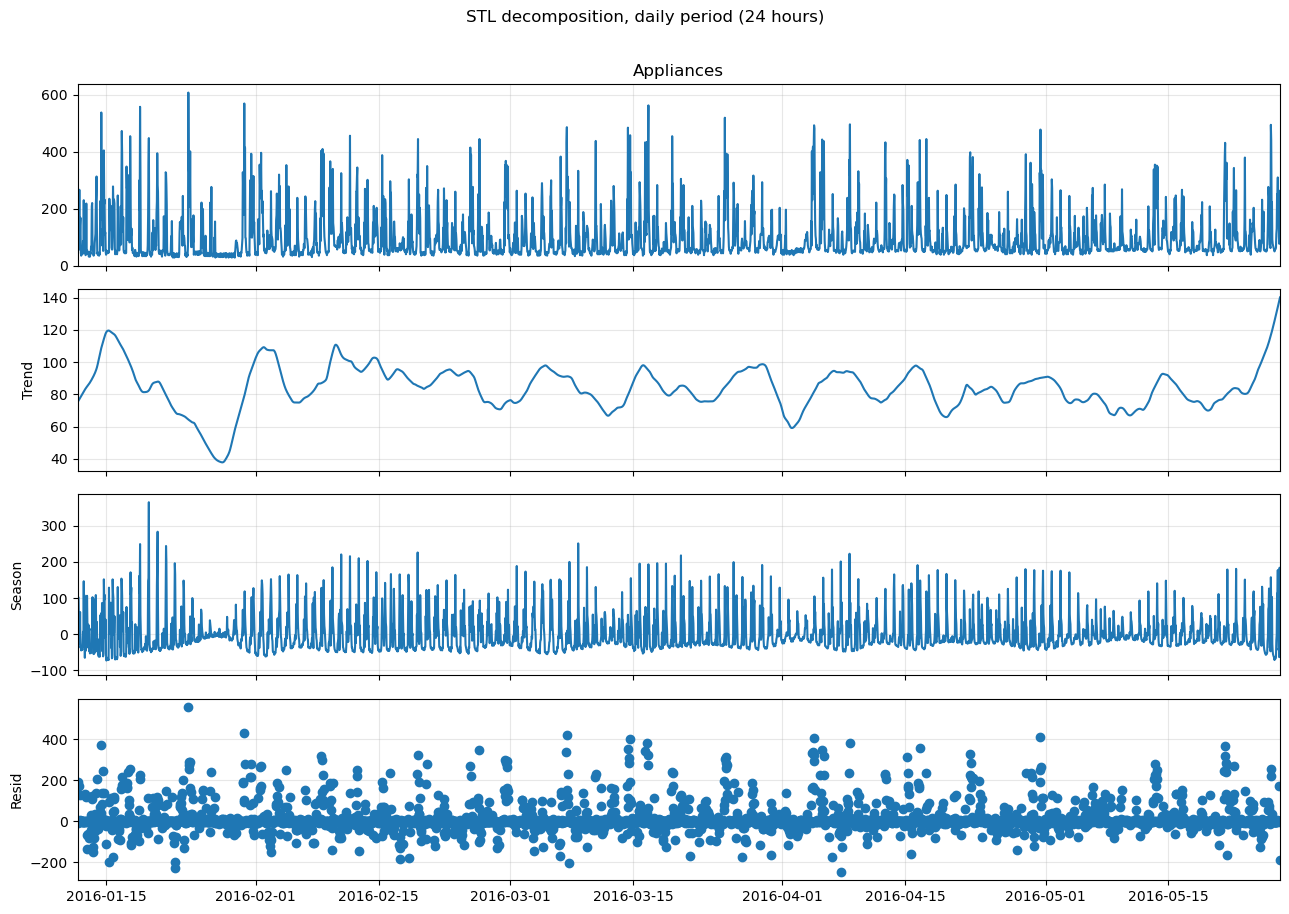

In [11]:
# 11. STL decomposition with a daily period

stl_result = STL(y, period=DAILY_PERIOD, robust=True).fit()

fig = stl_result.plot()
fig.set_size_inches(13, 9)
fig.suptitle("STL decomposition, daily period (24 hours)", y=1.01)

fig.tight_layout()
save_fig(fig, "02_stl_decomposition.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_mstl_decomposition.png


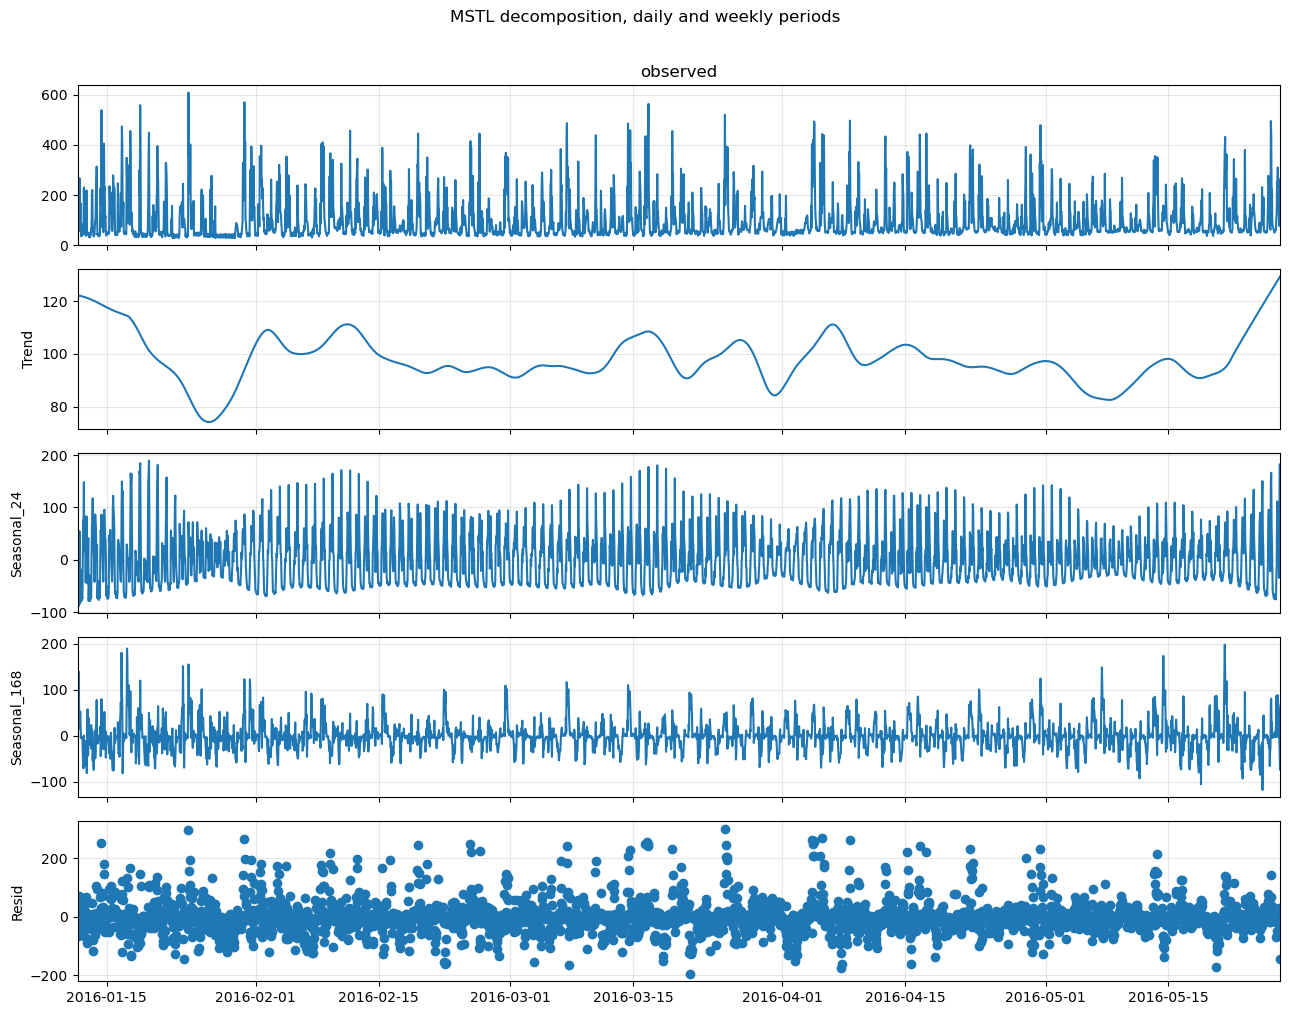

In [12]:
# 12. MSTL decomposition with daily and weekly periods

mstl_result = MSTL(y, periods=(DAILY_PERIOD, WEEKLY_PERIOD)).fit()

fig = mstl_result.plot()
fig.set_size_inches(13, 10)
fig.suptitle("MSTL decomposition, daily and weekly periods", y=1.01)

fig.tight_layout()
save_fig(fig, "02_mstl_decomposition.png")

plt.show()

In [13]:
# 13. Component strength

def component_strength(component, remainder):
    """Strength of a component, following Hyndman and Athanasopoulos (2021)."""

    return max(0.0, 1.0 - np.var(remainder) / np.var(component + remainder))


resid = mstl_result.resid

strengths = pd.Series({
    "trend": component_strength(mstl_result.trend, resid),
    "daily_seasonality": component_strength(mstl_result.seasonal["seasonal_24"], resid),
    "weekly_seasonality": component_strength(mstl_result.seasonal["seasonal_168"], resid),
})

variance_share = pd.Series({
    "trend": np.var(mstl_result.trend),
    "seasonal_24": np.var(mstl_result.seasonal["seasonal_24"]),
    "seasonal_168": np.var(mstl_result.seasonal["seasonal_168"]),
    "remainder": np.var(resid),
})

variance_share = variance_share / variance_share.sum()

print("Component strength (0 = negligible, 1 = dominant):")
print(strengths.round(3).to_string())

print("\nShare of total variance by component:")
print(variance_share.round(3).to_string())

Component strength (0 = negligible, 1 = dominant):
trend                 0.046
daily_seasonality     0.474
weekly_seasonality    0.298

Share of total variance by component:
trend           0.014
seasonal_24     0.375
seasonal_168    0.160
remainder       0.452


## 6. Autocorrelation structure

The ACF and PACF indicate how much of the current value is explained by its own past, and
are the standard diagnostic for choosing ARIMA orders.

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_acf_pacf.png


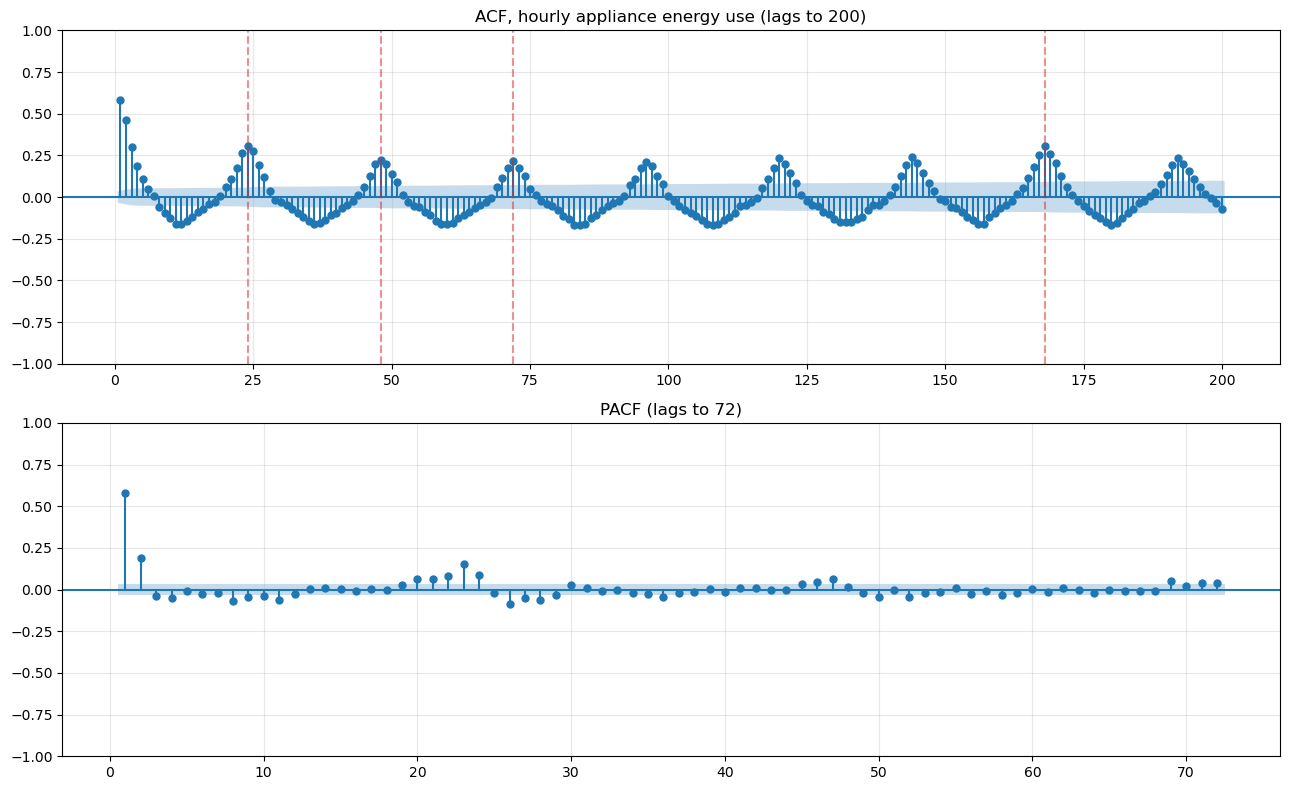

In [14]:
# 14. ACF and PACF of the level series

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

plot_acf(y, lags=200, ax=axes[0], zero=False)
axes[0].set_title("ACF, hourly appliance energy use (lags to 200)")

for lag in (24, 48, 72, 168):
    axes[0].axvline(lag, color="tab:red", linestyle="--", alpha=0.5)

plot_pacf(y, lags=72, ax=axes[1], method="ywm", zero=False)
axes[1].set_title("PACF (lags to 72)")

fig.tight_layout()
save_fig(fig, "02_acf_pacf.png")

plt.show()

In [15]:
# 15. Autocorrelation at the lags of practical interest

acf_values = acf(y, nlags=200)

lags_of_interest = [1, 2, 3, 6, 12, 24, 25, 48, 72, 168]

acf_table = pd.Series(
    {f"lag_{lag}": acf_values[lag] for lag in lags_of_interest},
    name="autocorrelation",
)

print(acf_table.round(3).to_string())

lag_1      0.581
lag_2      0.463
lag_3      0.301
lag_6      0.046
lag_12    -0.163
lag_24     0.304
lag_25     0.275
lag_48     0.221
lag_72     0.216
lag_168    0.306


## 7. Stationarity testing

Two complementary tests are used, because they have opposite null hypotheses:

* **ADF** (Augmented Dickey-Fuller): $H_0$ = a unit root is present (non-stationary).
  A small p-value is evidence *for* stationarity.
* **KPSS**: $H_0$ = the series is (trend-)stationary. A small p-value is evidence
  *against* stationarity.


In [16]:
# 16. ADF and KPSS across candidate transformations

def stationarity_tests(series, name):
    """Run ADF and KPSS on a series and return a summary."""

    series = pd.Series(series).dropna()

    with warnings.catch_warnings():
        # KPSS p-values come from a look-up table and are capped at 0.10 / 0.01,
        # which statsmodels reports as an InterpolationWarning.
        warnings.simplefilter("ignore")

        adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(series, autolag="AIC")
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression="c", nlags="auto")

    return {
        "series": name,
        "n": len(series),
        "ADF_stat": adf_stat,
        "ADF_p": adf_p,
        "ADF_5pct_crit": adf_crit["5%"],
        "ADF_conclusion": "stationary" if adf_p < 0.05 else "unit root",
        "KPSS_stat": kpss_stat,
        "KPSS_p": kpss_p,
        "KPSS_5pct_crit": kpss_crit["5%"],
        "KPSS_conclusion": "stationary" if kpss_p > 0.05 else "non-stationary",
    }


candidates = {
    "level": y,
    "log": np.log(y),
    "first difference": y.diff(),
    "seasonal difference (24)": y.diff(DAILY_PERIOD),
    "seasonal difference (168)": y.diff(WEEKLY_PERIOD),
    "first + seasonal difference": y.diff(DAILY_PERIOD).diff(),
    "log + seasonal difference": np.log(y).diff(DAILY_PERIOD),
}

stationarity = pd.DataFrame(
    [stationarity_tests(series, name) for name, series in candidates.items()]
).set_index("series")

stationarity.round(4)

,n,ADF_stat,ADF_p,ADF_5pct_crit,ADF_conclusion,KPSS_stat,KPSS_p,KPSS_5pct_crit,KPSS_conclusion
series,,,,,,,,,
level,3289,-9.0846,0.0,-2.8624,stationary,0.0413,0.1,0.463,stationary
log,3289,-8.1333,0.0,-2.8624,stationary,0.2694,0.1,0.463,stationary
first difference,3288,-16.9344,0.0,-2.8624,stationary,0.0203,0.1,0.463,stationary
seasonal difference (24),3265,-13.6427,0.0,-2.8624,stationary,0.0073,0.1,0.463,stationary
seasonal difference (168),3121,-20.5311,0.0,-2.8625,stationary,0.0948,0.1,0.463,stationary
first + seasonal difference,3264,-17.9943,0.0,-2.8624,stationary,0.0436,0.1,0.463,stationary
log + seasonal difference,3265,-12.9252,0.0,-2.8624,stationary,0.0101,0.1,0.463,stationary


Note that KPSS p-values are reported from a look-up table and are capped at 0.10, so a
value of exactly 0.10 should be read as "0.10 or greater" rather than as a precise
figure.

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_rolling_stats.png


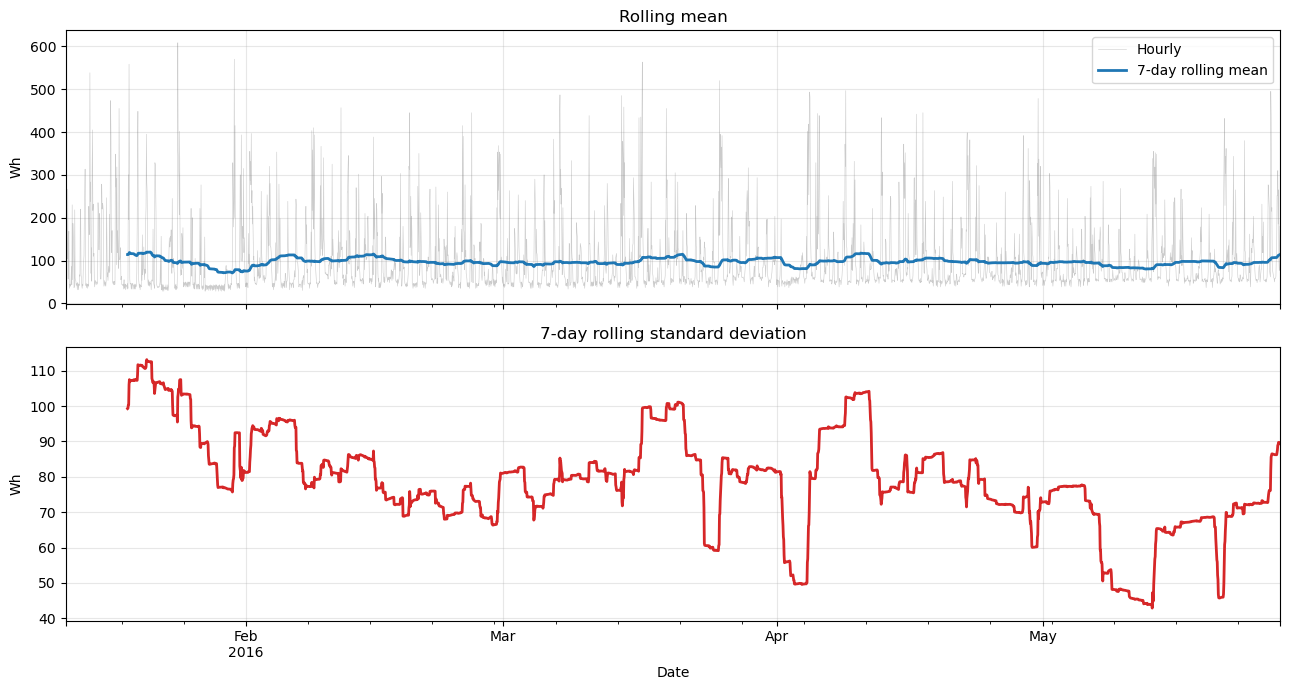

In [17]:
# 17. Rolling mean and standard deviation

window = 24 * 7

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

y.plot(ax=axes[0], linewidth=0.4, alpha=0.4, color="tab:grey", label="Hourly")
y.rolling(window).mean().plot(ax=axes[0], color="tab:blue", linewidth=2,
                              label="7-day rolling mean")
axes[0].set_title("Rolling mean")
axes[0].set_ylabel("Wh")
axes[0].legend()

y.rolling(window).std().plot(ax=axes[1], color="tab:red", linewidth=2)
axes[1].set_title("7-day rolling standard deviation")
axes[1].set_ylabel("Wh")
axes[1].set_xlabel("Date")

fig.tight_layout()
save_fig(fig, "02_rolling_stats.png")

plt.show()

In [18]:
# 18. Split-sample comparison of level and dispersion

bounds = np.linspace(0, len(y), 4).astype(int)

thirds = [y.iloc[bounds[i]:bounds[i + 1]] for i in range(3)]

split_stats = pd.DataFrame(
    [
        {
            "segment": f"third {i + 1}",
            "start": segment.index.min().date(),
            "end": segment.index.max().date(),
            "mean": segment.mean(),
            "std": segment.std(),
        }
        for i, segment in enumerate(thirds)
    ]
).set_index("segment")

split_stats.round(2)

,start,end,mean,std
segment,,,,
third 1,2016-01-11,2016-02-26,99.18,87.06
third 2,2016-02-26,2016-04-12,97.41,82.40
third 3,2016-04-12,2016-05-27,96.44,73.02


## 8. Covariates

The dataset supplies indoor sensor readings, outdoor weather and a lighting circuit
measurement. This section asks which of them carry information about appliance use, and
whether that information is contemporaneous or lagged.

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_correlation_heatmap.png


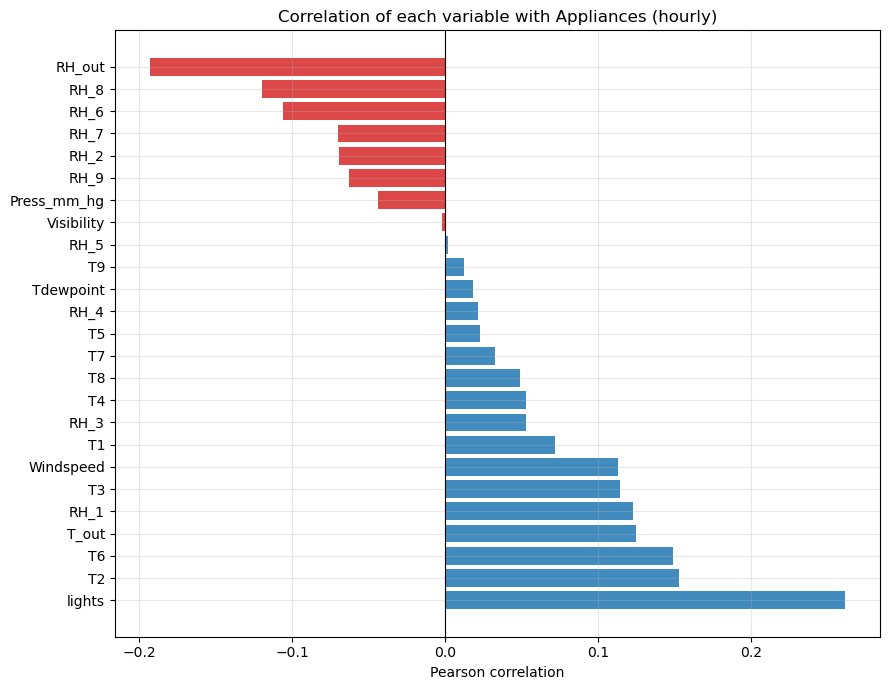

,lights,T2,T6,T_out,RH_1,T3,Windspeed,T1,RH_3,T4,T8,T7,T5,RH_4,Tdewpoint,T9,RH_5,Visibility,Press_mm_hg,RH_9,RH_2,RH_7,RH_6,RH_8,RH_out
correlation,0.261,0.153,0.149,0.124,0.123,0.114,0.113,0.072,0.053,0.053,0.049,0.033,0.022,0.021,0.018,0.012,0.002,-0.002,-0.044,-0.063,-0.07,-0.07,-0.106,-0.12,-0.193


In [19]:
# 19. Correlation of every variable with the target

correlations = (
    data.corr()[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))

colours = ["tab:blue" if v >= 0 else "tab:red" for v in correlations.values]

ax.barh(correlations.index, correlations.values, color=colours, alpha=0.85)
ax.set_title(f"Correlation of each variable with {TARGET} (hourly)")
ax.set_xlabel("Pearson correlation")
ax.axvline(0, color="black", linewidth=0.8)

fig.tight_layout()
save_fig(fig, "02_correlation_heatmap.png")

plt.show()

correlations.round(3).to_frame("correlation").T

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_correlation_matrix.png


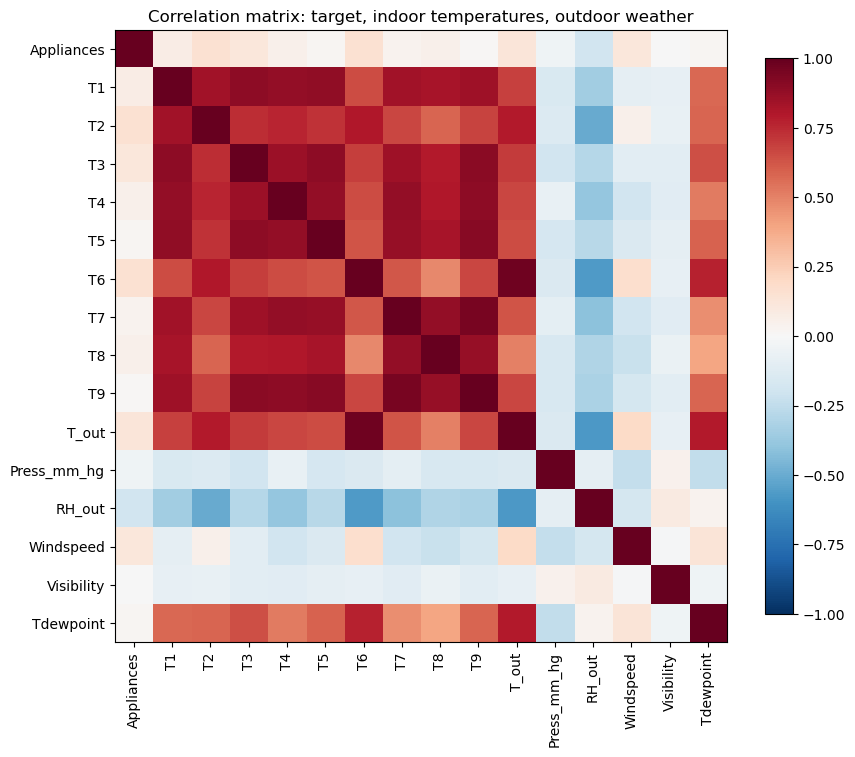

Mean absolute correlation among the nine indoor temperatures: 0.789


In [20]:
# 20. Correlation between covariates (multicollinearity check)

INDOOR_TEMP_COLS = [f"T{i}" for i in range(1, 10)]
INDOOR_HUM_COLS = [f"RH_{i}" for i in range(1, 10)]
OUTDOOR_COLS = ["T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility", "Tdewpoint"]

corr_matrix = data[[TARGET] + INDOOR_TEMP_COLS + OUTDOOR_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 8))

mesh = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix)), corr_matrix.index)
ax.set_title("Correlation matrix: target, indoor temperatures, outdoor weather")
ax.grid(False)

fig.colorbar(mesh, ax=ax, shrink=0.8)

fig.tight_layout()
save_fig(fig, "02_correlation_matrix.png")

plt.show()

print("Mean absolute correlation among the nine indoor temperatures:",
      round(float(data[INDOOR_TEMP_COLS].corr().abs().values[np.triu_indices(9, k=1)].mean()), 3))

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\02_lagged_correlation.png


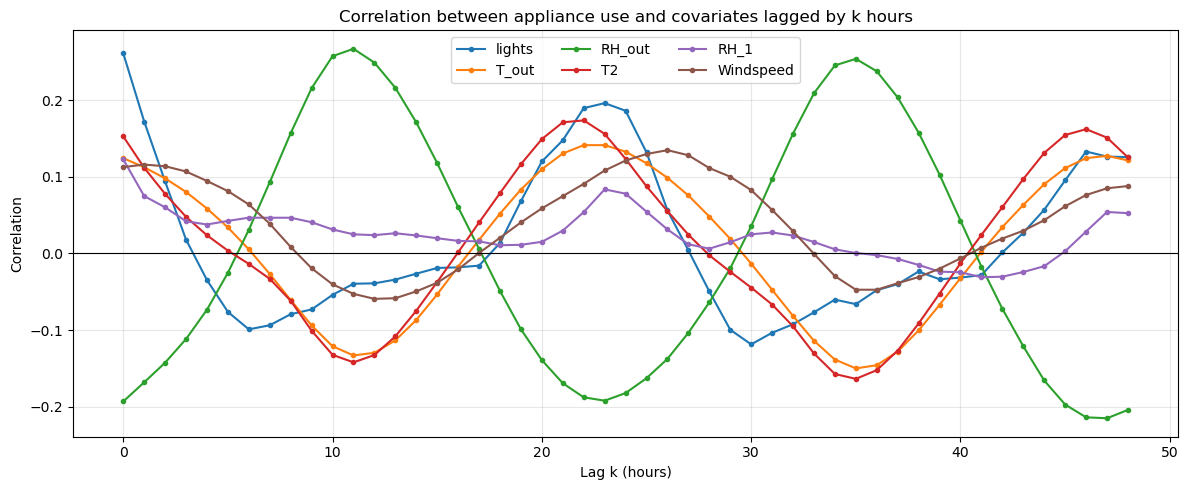

,lights,T_out,RH_out,T2,RH_1,Windspeed
0,0.261,0.124,-0.193,0.153,0.123,0.113
1,0.172,0.113,-0.168,0.112,0.075,0.116
2,0.094,0.098,-0.143,0.078,0.060,0.114
3,0.018,0.080,-0.112,0.048,0.042,0.107
6,-0.099,0.005,0.031,-0.014,0.047,0.064
12,-0.039,-0.130,0.249,-0.133,0.024,-0.059
24,0.186,0.133,-0.182,0.124,0.078,0.121


In [21]:
# 21. Lagged cross-correlation with selected covariates

def lagged_correlation(target, covariate, max_lag=48):
    """
    Correlation between the target and a covariate shifted forward by k hours.

    A positive lag k means the covariate value from k hours ago is compared with
    the current target value, which is the direction usable in a real forecast.
    """

    return pd.Series(
        {lag: target.corr(covariate.shift(lag)) for lag in range(0, max_lag + 1)},
        name=covariate.name,
    )


selected = ["lights", "T_out", "RH_out", "T2", "RH_1", "Windspeed"]

lag_corr = pd.DataFrame({
    col: lagged_correlation(y, data[col]) for col in selected
})

fig, ax = plt.subplots(figsize=(12, 5))

for col in lag_corr.columns:
    ax.plot(lag_corr.index, lag_corr[col], marker="o", markersize=3, label=col)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlation between appliance use and covariates lagged by k hours")
ax.set_xlabel("Lag k (hours)")
ax.set_ylabel("Correlation")
ax.legend(ncol=3)

fig.tight_layout()
save_fig(fig, "02_lagged_correlation.png")

plt.show()

lag_corr.loc[[0, 1, 2, 3, 6, 12, 24]].round(3)

In [22]:
# 22. Do covariates add anything beyond time of day?

# Remove the average daily profile from the target and from each covariate,
# then re-correlate. What survives is information not already carried by the
# hour of day.

def remove_daily_profile(series):
    profile = series.groupby(series.index.hour).transform("mean")
    return series - profile


y_detrended = remove_daily_profile(y)

partial = pd.Series({
    col: y_detrended.corr(remove_daily_profile(data[col]))
    for col in selected + ["Tdewpoint", "Visibility", "T6", "RH_6"]
}).sort_values(key=abs, ascending=False)

comparison = pd.DataFrame({
    "raw_correlation": data[partial.index].corrwith(y),
    "after_removing_hour_of_day": partial,
}).round(3)

comparison

,raw_correlation,after_removing_hour_of_day
lights,0.261,0.194
RH_1,0.123,0.103
RH_out,-0.193,0.040
Windspeed,0.113,0.034
T2,0.153,0.030
T_out,0.124,-0.019
RH_6,-0.106,0.017
T6,0.149,-0.014
Visibility,-0.002,0.008
Tdewpoint,0.018,0.006
